# Orbital Threat Assessment — PHA Classification: Narrative Walkthrough

This notebook tells the project's story end to end: the data, NASA's own
PHA definition, the supervised classification results, and a secondary
unsupervised analysis — using the *actual* rebuilt pipeline, not a
reimplementation of it.

**This notebook is a thin narrative layer, not a source of truth.** Every
number here is read live from the same artifacts the rest of the repo
produces:

- Data comes from the dbt marts (`dbt/models/marts/`), via `otda.data`
- Model results come from the MLflow tracking store (`mlflow.db`), via
  `otda.tracking` — the same store [`RESULTS.md`](../RESULTS.md) is
  generated from
- The served model comes from `models/champion/`, via `otda.inference`
- Clustering reruns the same functions in `otda.cluster` that produced
  [`CLUSTERING_RESULTS.md`](../CLUSTERING_RESULTS.md)

No cleaning, training, or clustering logic is reimplemented here — all of
that lives in `dbt/` and `src/otda/`. See the main [`README.md`](../README.md)
for how to run each stage for real, and `legacy/Project_codeFile.ipynb`
for the original, frozen coursework submission this rebuild replaces.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd

from otda import cluster as otda_cluster
from otda.agent import fetch_asteroid_impl
from otda.data import CLUSTER_FEATURES, load_class_map, load_modeling_data, load_orbital_elements
from otda.inference import H_THRESHOLD, MOID_THRESHOLD_AU, explain, load_model, predict
from otda.tracking import get_tracking_db

pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (7, 4.5)

C:\Users\aksha\Documents\Projects\orbital-threat-private-dev\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/09/18 02:04:54 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\aksha\Documents\Projects\orbital-threat-private-dev\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


## 1. The dataset and the class imbalance

`fct_asteroids_modeling` is the full cleaned population (see the main
README for how it differs from the notebook's original 100K sample):
outlier caps applied, HYA rows dropped, `class` encoded via the versioned
seed. `is_pha` is the target — and it's badly imbalanced, which is the
whole reason this project uses SMOTE (train-only) and reports PR-AUC
rather than accuracy.

In [2]:
from otda.features import EXP2_FEATURES

data = load_modeling_data(EXP2_FEATURES)
print(f"{len(data.X):,} rows, {data.X.shape[1]} features: {list(data.X.columns)}")

counts = data.y.value_counts().sort_index()
ratio = counts[0] / counts[1]
print(f"Not-PHA: {counts[0]:,}   PHA: {counts[1]:,}   ratio {ratio:.0f}:1")

932,335 rows, 6 features: ['e', 'q', 'H', 'is_neo', 'class_code', 'moid']
Not-PHA: 930,269   PHA: 2,066   ratio 450:1


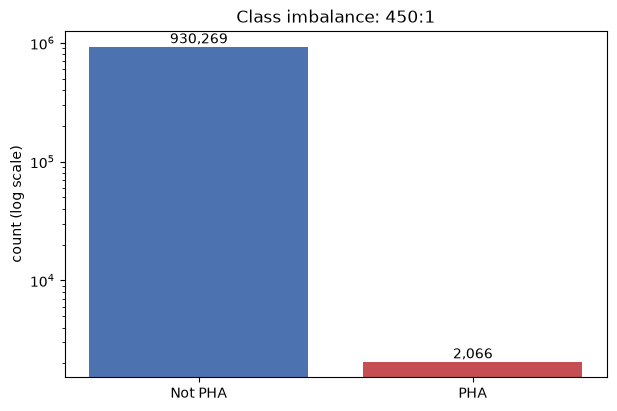

In [3]:
fig, ax = plt.subplots()
ax.bar(["Not PHA", "PHA"], counts.values, color=["#4c72b0", "#c44e52"])
ax.set_yscale("log")
ax.set_ylabel("count (log scale)")
ax.set_title(f"Class imbalance: {ratio:.0f}:1")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.show()

## 2. NASA's own PHA definition

A PHA is defined by NASA/JPL CNEOS as an object with **MOID ≤ 0.05 AU**
*and* **H ≤ 22.0** — a hazard-proximity condition and a size-proxy
condition, both required. This is a hard geometric rule, not something
learned from labels; Experiment 2 below includes MOID as a feature
specifically because it lets a tree-based model reconstruct this rule
directly rather than approximate it.

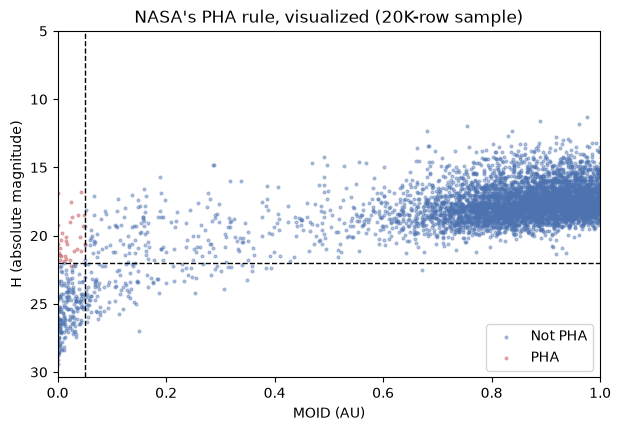

In [4]:
sample = data.X.sample(n=20_000, random_state=42)
sample_y = data.y.loc[sample.index]

fig, ax = plt.subplots()
for label, colour, name in [(0, "#4c72b0", "Not PHA"), (1, "#c44e52", "PHA")]:
    mask = sample_y == label
    ax.scatter(sample.loc[mask, "moid"], sample.loc[mask, "H"], s=4, alpha=0.4, color=colour, label=name)

ax.axvline(MOID_THRESHOLD_AU, color="black", linestyle="--", linewidth=1)
ax.axhline(H_THRESHOLD, color="black", linestyle="--", linewidth=1)
ax.set_xlim(0, 1.0)
ax.set_ylim(sample["H"].max() + 1, 5)  # smaller H = larger, more hazardous object
ax.set_xlabel("MOID (AU)")
ax.set_ylabel("H (absolute magnitude)")
ax.set_title("NASA's PHA rule, visualized (20K-row sample)")
ax.legend(loc="lower right")
plt.show()

## 3. Supervised results — read live from MLflow

Both experiments' test-set metrics, pulled directly from the tracking
store (`scripts/run_experiments.py` populates it; `scripts/generate_results_table.py`
generates [`RESULTS.md`](../RESULTS.md) from the same source). Test-set
metrics are touched exactly once per run, after model selection on the
validation set — see `src/otda/train.py`.

In [5]:
mlflow.set_tracking_uri(f"sqlite:///{get_tracking_db().as_posix()}")

runs = mlflow.search_runs(
    experiment_names=["orbital_threat_assessment"],
    filter_string="params.dataset = 'full_population_932335'",
)

results = (
    runs[["params.feature_set", "params.model_name", "metrics.test_recall",
          "metrics.test_precision", "metrics.test_f1", "metrics.test_pr_auc", "metrics.test_roc_auc"]]
    .rename(columns=lambda c: c.replace("params.", "").replace("metrics.test_", ""))
    .sort_values(["feature_set", "pr_auc"], ascending=[True, False])
    .reset_index(drop=True)
)
results

,feature_set,model_name,recall,precision,f1,pr_auc,roc_auc
0,exp1_orbital_only,decision_tree,0.9976,0.3433,0.5108,0.6778,0.9969
1,exp1_orbital_only,random_forest,0.9831,0.3587,0.5256,0.4496,0.9984
2,exp1_orbital_only,logistic_regression,1.0000,0.1492,0.2596,0.2578,0.9968
3,exp1_orbital_only,linear_svc,1.0000,0.1507,0.2620,0.2423,0.9965
4,exp2_moid_included,decision_tree,0.9855,0.9443,0.9645,0.9988,1.0000
5,exp2_moid_included,random_forest,0.9903,0.9381,0.9635,0.9967,1.0000
6,exp2_moid_included,linear_svc,1.0000,0.4126,0.5842,0.8209,0.9996
7,exp2_moid_included,logistic_regression,1.0000,0.3402,0.5077,0.8137,0.9996


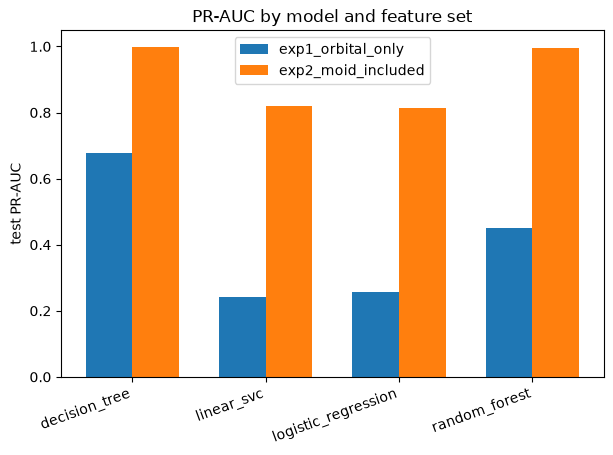

In [6]:
fig, ax = plt.subplots()
width = 0.35
feature_sets = results["feature_set"].unique()
for offset, feature_set in zip([-width / 2, width / 2], feature_sets):
    subset = results[results["feature_set"] == feature_set].sort_values("model_name")
    positions = np.arange(len(subset)) + offset
    ax.bar(positions, subset["pr_auc"], width=width, label=feature_set)

ax.set_xticks(np.arange(len(subset)))
ax.set_xticklabels(subset["model_name"].values, rotation=20, ha="right")
ax.set_ylabel("test PR-AUC")
ax.set_title("PR-AUC by model and feature set")
ax.legend()
plt.show()

**Why Experiment 2 is near-perfect and Experiment 1 isn't:** MOID is part
of NASA's own two-condition PHA definition, so a tree given that feature
is learning the label's own definitional boundary, not an independent
signal — Experiment 1 (no MOID) improves only modestly over the legacy
notebook's numbers, which is the expected sanity check. Full discussion
in [`RESULTS.md`](../RESULTS.md).

## 4. The champion model, on real asteroids

The champion (Decision Tree, Experiment 2 — see `models/champion/`) is
exercised here through the exact same shared inference path the FastAPI
app and the LangChain agent use (`otda.inference.predict`), against real
looked-up asteroid records (`otda.agent.fetch_asteroid_impl` — the same
lookup the agent's `fetch_asteroid` tool calls).

In [7]:
model = load_model()

for name in ["Apophis", "433 Eros", "'Oumuamua"]:
    record = fetch_asteroid_impl(name)
    if record is None:
        print(f"{name}: not found\n")
        continue
    result = predict(model, record)
    print(f"--- {name} (spkid {record['spkid']}) ---")
    print(result.explanation)
    print()

--- Apophis (spkid 2099942) ---
Model prediction: potentially hazardous (probability=1.000). NASA's PHA definition requires MOID <= 0.05 AU AND H <= 22.0. This object has MOID = 0.0003 AU (<= 0.05 AU, condition met) and H = 19.70 (<= 22.0, condition met). The model's prediction is consistent with NASA's two-condition rule applied directly to this object's MOID and H.

--- 433 Eros (spkid 2000433) ---
Model prediction: not potentially hazardous (probability=0.000). NASA's PHA definition requires MOID <= 0.05 AU AND H <= 22.0. This object has MOID = 0.1486 AU (> 0.05 AU, condition not met) and H = 10.40 (<= 22.0, condition met). The model's prediction is consistent with NASA's two-condition rule applied directly to this object's MOID and H.



'Oumuamua: not found



`'Oumuamua` is expected to come back as "not found" here — it's one of
the four HYA (hyperbolic-orbit) rows dropped from `fct_asteroids_modeling`
during cleaning (see `dbt/models/staging/stg_asteroids.sql`'s comments):
NEO status is genuinely undefined for a body on a hyperbolic trajectory,
not just missing data, so it's excluded rather than defaulted.

## 5. Secondary analysis: do orbital elements alone recover the known classes?

Independent of PHA classification — do `a, e, i, moid, H` alone recover
the 13 known dynamical classes (AMO/APO/MBA/...)? This reruns the same
`otda.cluster` functions behind [`CLUSTERING_RESULTS.md`](../CLUSTERING_RESULTS.md)
live, rather than reproducing its numbers by hand. KMeans runs against
the full population; HDBSCAN against a 100K sample (its complexity makes
the full population impractical here — see `otda/cluster.py`'s docstring).

In [8]:
orbital = load_orbital_elements("fct_asteroids_modeling")
X_scaled = otda_cluster.scale_features(orbital, CLUSTER_FEATURES)

kmeans_result = otda_cluster.run_kmeans(X_scaled, orbital["class_code"])

# Same dbt-materialized stratified sample scripts/run_clustering.py uses
# for HDBSCAN -- not a fresh pandas .sample() over the full population,
# which would be a different (and non-canonical) 100K rows.
sample_orbital = load_orbital_elements("fct_asteroids_sample_100k")
X_sample_scaled = otda_cluster.scale_features(sample_orbital, CLUSTER_FEATURES)
hdbscan_result = otda_cluster.run_hdbscan(X_sample_scaled, sample_orbital["class_code"])

pd.DataFrame([kmeans_result.__dict__, hdbscan_result.__dict__])

,method,n_clusters_found,ari,nmi,noise_fraction
0,kmeans,13,0.0344,0.2235,0.0000
1,hdbscan,10,0.4610,0.3979,0.1498


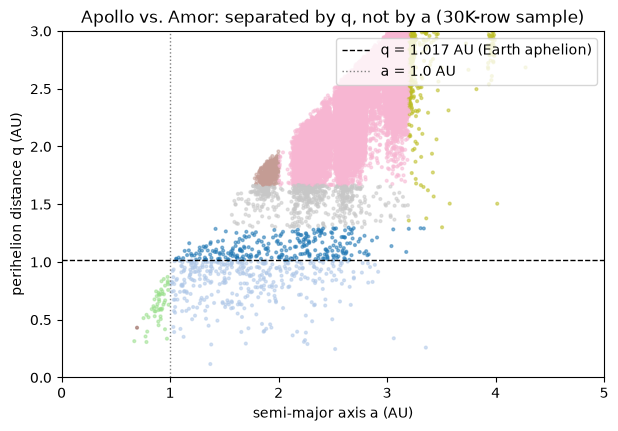

In [9]:
import duckdb

from otda.data import DEFAULT_DB

# q (perihelion distance) isn't one of CLUSTER_FEATURES -- it's not used
# by any model, only needed here to show the Apollo/Amor boundary. Pulled
# directly rather than added to otda.data, which is scoped to modeling
# features only.
with duckdb.connect(str(DEFAULT_DB), read_only=True) as con:
    q_by_spkid = con.execute(
        "select spkid, q from main.fct_asteroids_modeling"
    ).df()

orbital_with_q = orbital.merge(q_by_spkid, on="spkid")

class_map = load_class_map()
code_to_abbr = {v: k for k, v in class_map.items()}

fig, ax = plt.subplots()
plot_sample = orbital_with_q.sample(n=30_000, random_state=42)
scatter = ax.scatter(
    plot_sample["a"], plot_sample["q"], c=plot_sample["class_code"],
    cmap="tab20", s=4, alpha=0.5,
)
ax.axhline(1.017, color="black", linestyle="--", linewidth=1, label="q = 1.017 AU (Earth aphelion)")
ax.axvline(1.0, color="grey", linestyle=":", linewidth=1, label="a = 1.0 AU")
ax.set_xlim(0, 5)
ax.set_ylim(0, 3)
ax.set_xlabel("semi-major axis a (AU)")
ax.set_ylabel("perihelion distance q (AU)")
ax.set_title("Apollo vs. Amor: separated by q, not by a (30K-row sample)")
ax.legend(loc="upper right")
plt.show()

KMeans and HDBSCAN both land well short of perfectly recovering the 13
classes — expected, not a failure: Apollo and Amor share `a > 1.0 AU`
entirely and are only separated by `q` relative to 1.017 AU (Earth's
aphelion), a sharp geometric threshold rather than a natural density gap.
Full three-method comparison (including k-NN graph + Louvain) and the
complete reasoning are in [`CLUSTERING_RESULTS.md`](../CLUSTERING_RESULTS.md).

## Where to go from here

- [`README.md`](../README.md) — full repository layout and how to run
  every stage (dbt, training, serving, the agent, cloud infra)
- [`RESULTS.md`](../RESULTS.md) — complete supervised-learning results
- [`CLUSTERING_RESULTS.md`](../CLUSTERING_RESULTS.md) — complete
  unsupervised-analysis results
- `legacy/Project_codeFile.ipynb` — the original, frozen coursework
  submission this rebuild replaces